In [16]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel))
library(tidyr)
library(foreach)
library(doParallel)
library(tidygraph)
library(anndata)
suppressMessages(library(cowplot))
# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)


In [ ]:
data1 = read_h5ad('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/VTA.h5ad')
data2 = read_h5ad('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/IP-VTA.h5ad')
data2 = read_h5ad('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/IP-VTA.h5ad')
seurat1 = CreateSeuratObject(counts = t(data1$X),meta.data = data1$obs)
seurat2 = CreateSeuratObject(counts = t(data2$X),meta.data = data2$obs)
seurat3 = CreateSeuratObject(counts = t(data3$X),meta.data = data3$obs)
seurat = merge(seurat1,seurat2)

Warning message:
“Data is of class dgRMatrix. Coercing to dgCMatrix.”
Warning message:
“Data is of class dgRMatrix. Coercing to dgCMatrix.”


In [8]:
seurat = JoinLayers(seurat)
seurat

An object of class Seurat 
20357 features across 100837 samples within 1 assay 
Active assay: RNA (20357 features, 0 variable features)
 1 layer present: counts

In [9]:
seurat@meta.data %>% head()

,orig.ident,nCount_RNA,nFeature_RNA,Species,Animal,sample_name,Library,main.structure,area,path,matrix_dir
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
cDNA-250114094:CELL1_N5,SeuratProject,1429,956,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix
cDNA-250114094:CELL2_N4,SeuratProject,1504,1006,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix
cDNA-250114094:CELL3_N2,SeuratProject,15703,5051,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix
cDNA-250114094:CELL5_N4,SeuratProject,1531,972,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix
cDNA-250114094:CELL7_N5,SeuratProject,2675,1713,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix
cDNA-250114094:CELL8_N5,SeuratProject,4121,2113,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix


In [10]:
data <- read_h5ad("/mnt/90-connectome/Personal/CQW/motor_files/motor_10_samples_concat.h5ad")
seurat <- CreateSeuratObject(counts = t(data$X), meta.data = data$obs)
cellNum2 <- ncol(seurat) # nolint
cellNum2
sample_cellNum <- table(seurat$samples)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Data is of class dgRMatrix. Coercing to dgCMatrix.”


[1] 339698

In [11]:
seurat$countFeatureRatio <- seurat$nCount_RNA / seurat$nFeature_RNA
MTGenes <- c("ND6","COX1","ND5","ND4","ND2","ND4L","ATP8","CYTB","COX2","ND3","ATP6","ND1","COX3")
seurat[["percent.mt"]] <- colSums(x = GetAssayData(object = seurat, assay = "RNA", layer = "counts")
    [MTGenes, , drop = FALSE])/seurat[[paste0("nCount_","RNA")]] * 100

In [21]:
seurat = subset(seurat, nFeature_RNA > 300 & percent.mt < 5 
& countFeatureRatio > 1.2
& countFeatureRatio < 10000
& nCount_RNA < 50000)
cellNum1 = ncol(seurat)
message("Filter ratio: ", cellNum1/cellNum2)
sample_cellNum_filter <- table(seurat$samples)
sample_ratial <- sample_cellNum_filter / sample_cellNum
sample_ratial

Filter ratio: 0.783392896042956




        1         2         3         4         5         6         7         8 
0.7634846 0.8953826 0.5233611 0.9076632 0.9607227 0.9077765 0.9284904 0.9212759 
        9        10 
0.8593803 0.8991757 

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



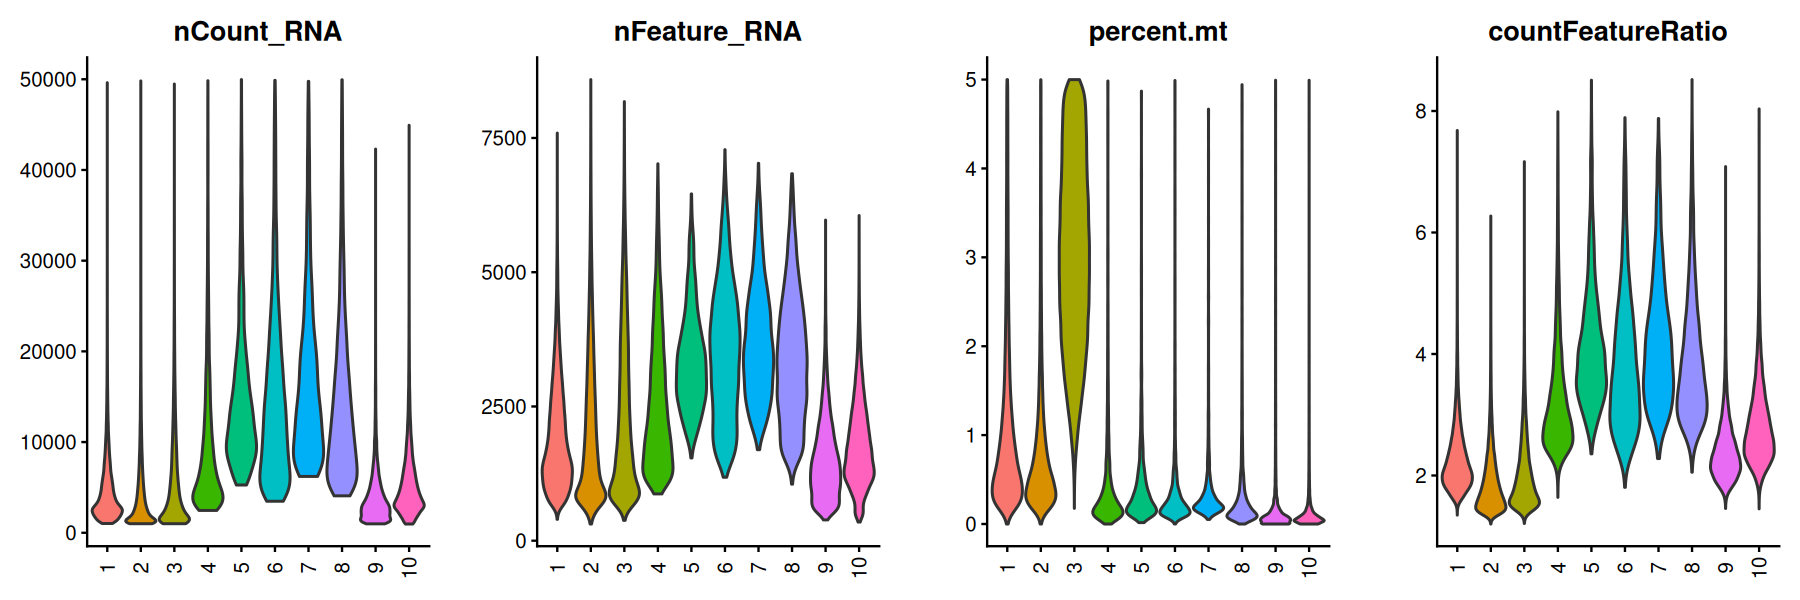

In [22]:
Idents(seurat) = "samples"
options(repr.plot.width=15, repr.plot.height=5)
print(plot_grid(
    plotlist = lapply(c("nCount_RNA", "nFeature_RNA", "percent.mt", "countFeatureRatio"), function(x) {
        p = VlnPlot(seurat, features=x, pt.size=0) + 
            theme(axis.text.x=element_text(vjust=0.5, hjust=0.5, angle=90), axis.title.x = element_blank()) +
            guides(fill=FALSE)
        return(p)
    }), 
    ncol=4, align="hv", axis="tblr"
))

In [ ]:
SCTseurat = SCTransform(
    seurat, assay="RNA",
    ncells=ncol(seurat[["RNA"]]),
    variable.features.n=5000,
    vars.to.regress="percent.mt",
    return.only.var.genes = T,
    method="glmGamPoi"
)

Running SCTransform on assay: RNA

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi

